# Imports

In [2]:
import os

print("Before:", os.getcwd())

Before: /home/yoshi0428/PycharmProjects/osu-predict/backend/osu_oracle_pytorch


In [6]:
os.chdir('//')

In [7]:
import os
import pickle
import time
from collections import Counter
import numpy as np
import torch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from osu_oracle_pytorch.oracle.utils_training import (get_data, get_additional_features, pad_sequences_pt,
                                                      train_and_evaluate, plot_training_history, load_pytorch_models)
from osu_oracle_pytorch.oracle.pruning import prune_models
from osu_oracle_pytorch.oracle.augment import augment_dataset

In [8]:
# from backend.osu_oracle_pytorch.oracle.previous_cnn_model import CNN_Model
from osu_oracle_pytorch.oracle.cnn_model import CNN_Model

# Model Testing

Go run test_model.py

# Setup

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

db_path = 'beatmaps.db'

# augments make the dataset too damn big for my 64GB RAM
# even then, this isn't quite the right spot to augment at... you'd want to augment it right after train_test_split
# if you decide to augment here anyway, there might be something you can do with the beatmap_ids variable
X, y, beatmap_ids = get_data(db_path)

additional_features = get_additional_features(db_path)

additional_features_array = np.array([
    additional_features[beatmap_id]
    for beatmap_id in beatmap_ids
])

OperationalError: no such table: beatmap_vectors

In [4]:
print(additional_features_array.shape)

(29702, 10)


In [5]:
sequence_lengths = np.array([len(seq) for seq in X])

print("Number of beatmaps:", len(sequence_lengths))
print("Min:", sequence_lengths.min())
print("Median:", np.median(sequence_lengths))
print("Mean:", sequence_lengths.mean())
print("75th:", np.percentile(sequence_lengths, 75))
print("90th:", np.percentile(sequence_lengths, 90))
print("95th:", np.percentile(sequence_lengths, 95))
print("99th:", np.percentile(sequence_lengths, 99))
print("Max:", sequence_lengths.max())

Number of beatmaps: 29702
Min: 1
Median: 781.0
Mean: 929.138138845869
75th: 1154.0
90th: 1740.0
95th: 2172.949999999997
99th: 3205.979999999996
Max: 27570


In [6]:
X_train, X_test, y_train, y_test, beatmap_ids_train, beatmap_ids_test, features_train, features_test = train_test_split(
    X,
    y,
    beatmap_ids,
    additional_features_array,
    test_size=0.2,
    random_state=42,
    # stratify=y
)

# AUGMENT TRAINING DATA ONLY
X_train, y_train, beatmap_ids_train = augment_dataset(
    X_train,
    y_train,
    beatmap_ids_train,

    augmentation_types={
        "horizontal",
        "vertical",
        "horizontal_vertical",
    },

    # None = augment every training beatmap
    augmentation_ids=None,
)

# Duplicate additional features for augmented samples
features_train = np.array([
    additional_features[beatmap_id]
    for beatmap_id in beatmap_ids_train
])

print(f"Final train size: {len(X_train)}")
print(f"Final test size:  {len(X_test)}")
print(f"Train features:   {features_train.shape}")
print(f"Test features:    {features_test.shape}")

# Encode labels
label_encoder = LabelEncoder()
label_encoder.fit(y)

with open('models/label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

y_train_numerical = label_encoder.transform(y_train)
y_test_numerical = label_encoder.transform(y_test)
num_classes = len(label_encoder.classes_)

y_train_numerical = torch.tensor(y_train_numerical, dtype=torch.long)
y_test_numerical = torch.tensor(y_test_numerical, dtype=torch.long)

# Pad sequences
sequence_lengths = np.array([len(seq) for seq in X])
max_length = int(np.percentile(sequence_lengths, 99))
max_length = 2 ** int(np.ceil(np.log2(max_length)))
max_length = min(max_length, 4096)
print(f"Using max sequence length: {max_length}")

X_train = pad_sequences_pt(
    X_train,
    maxlen=max_length,
    dtype=torch.float32
)
X_test = pad_sequences_pt(
    X_test,
    maxlen=max_length,
    dtype=torch.float32
)

print(X_train.shape)
print(X_test.shape)

Augmentation: ENABLED
Augmentation types: ['horizontal', 'horizontal_vertical', 'vertical']
Augmentation IDs: ALL
Original training samples: 23761
Augmented training samples: 95044
Final train size: 95044
Final test size:  5941
Train features:   (95044, 10)
Test features:    (5941, 10)
Using max sequence length: 4096
torch.Size([95044, 4096, 4])
torch.Size([5941, 4096, 4])


In [7]:
# (batch, sequence_length, features)
# but Conv1d expects (batch, channels, sequence_length)
X_train = X_train.permute(0, 2, 1)
X_test = X_test.permute(0, 2, 1)

print(X_train.shape)
print(X_test.shape)

torch.Size([95044, 4, 4096])
torch.Size([5941, 4, 4096])


In [8]:
class_counts = Counter(y_train_numerical.numpy())

for cls, count in sorted(class_counts.items()):
    print(f"Class {cls}: {count}")

Class 0: 5780
Class 1: 7596
Class 2: 2528
Class 3: 6912
Class 4: 3452
Class 5: 3972
Class 6: 8376
Class 7: 7768
Class 8: 4776
Class 9: 8596
Class 10: 6676
Class 11: 7936
Class 12: 6948
Class 13: 3568
Class 14: 6720
Class 15: 3440


# CNN Model Training

Epoch 1/30 - loss: 2.5612 - acc: 0.1615 - val_loss: 2.4102 - val_acc: 0.2144
Epoch 2/30 - loss: 2.4288 - acc: 0.2039 - val_loss: 2.3475 - val_acc: 0.2311
Epoch 3/30 - loss: 2.3924 - acc: 0.2167 - val_loss: 2.3196 - val_acc: 0.2410
Epoch 4/30 - loss: 2.3698 - acc: 0.2225 - val_loss: 2.2854 - val_acc: 0.2515
Epoch 5/30 - loss: 2.3490 - acc: 0.2296 - val_loss: 2.2715 - val_acc: 0.2405
Epoch 6/30 - loss: 2.3289 - acc: 0.2349 - val_loss: 2.2657 - val_acc: 0.2607
Epoch 7/30 - loss: 2.3112 - acc: 0.2434 - val_loss: 2.2511 - val_acc: 0.2676
Epoch 8/30 - loss: 2.2940 - acc: 0.2461 - val_loss: 2.2503 - val_acc: 0.2653
Epoch 9/30 - loss: 2.2827 - acc: 0.2496 - val_loss: 2.2518 - val_acc: 0.2597
Epoch 10/30 - loss: 2.2690 - acc: 0.2517 - val_loss: 2.2153 - val_acc: 0.2767
Epoch 11/30 - loss: 2.2562 - acc: 0.2581 - val_loss: 2.2178 - val_acc: 0.2779
Epoch 12/30 - loss: 2.2449 - acc: 0.2601 - val_loss: 2.2341 - val_acc: 0.2665
Epoch 13/30 - loss: 2.2335 - acc: 0.2619 - val_loss: 2.2023 - val_acc: 0.

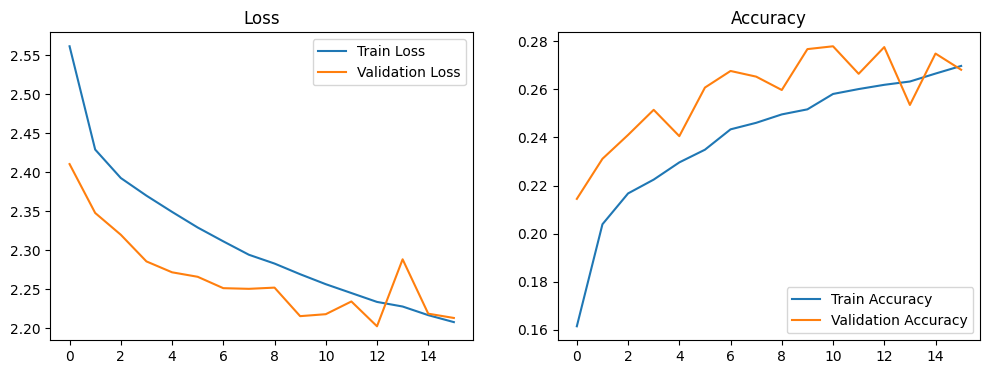

Epoch 1/30 - loss: 2.5523 - acc: 0.1620 - val_loss: 2.3991 - val_acc: 0.2200
Epoch 2/30 - loss: 2.4184 - acc: 0.2103 - val_loss: 2.3416 - val_acc: 0.2358
Epoch 3/30 - loss: 2.3838 - acc: 0.2193 - val_loss: 2.3184 - val_acc: 0.2325
Epoch 4/30 - loss: 2.3581 - acc: 0.2272 - val_loss: 2.3079 - val_acc: 0.2426
Epoch 5/30 - loss: 2.3391 - acc: 0.2319 - val_loss: 2.2797 - val_acc: 0.2557
Epoch 6/30 - loss: 2.3198 - acc: 0.2376 - val_loss: 2.2598 - val_acc: 0.2644
Epoch 7/30 - loss: 2.3052 - acc: 0.2420 - val_loss: 2.2797 - val_acc: 0.2589
Epoch 8/30 - loss: 2.2939 - acc: 0.2442 - val_loss: 2.2302 - val_acc: 0.2722
Epoch 9/30 - loss: 2.2766 - acc: 0.2508 - val_loss: 2.2389 - val_acc: 0.2646
Epoch 10/30 - loss: 2.2687 - acc: 0.2536 - val_loss: 2.2169 - val_acc: 0.2727
Epoch 11/30 - loss: 2.2566 - acc: 0.2560 - val_loss: 2.2257 - val_acc: 0.2744
Epoch 12/30 - loss: 2.2451 - acc: 0.2585 - val_loss: 2.2317 - val_acc: 0.2703
Epoch 13/30 - loss: 2.2374 - acc: 0.2613 - val_loss: 2.2471 - val_acc: 0.

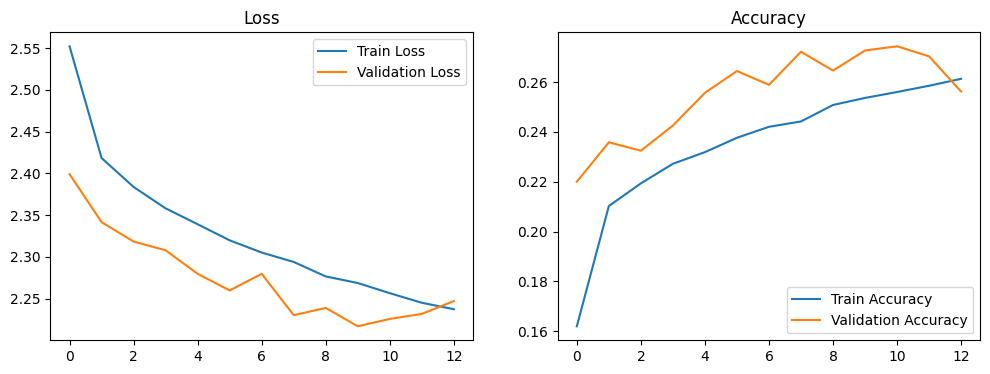

Epoch 1/30 - loss: 2.6108 - acc: 0.1421 - val_loss: 2.4388 - val_acc: 0.2005
Epoch 2/30 - loss: 2.4719 - acc: 0.1897 - val_loss: 2.3863 - val_acc: 0.2286
Epoch 3/30 - loss: 2.4273 - acc: 0.2016 - val_loss: 2.3320 - val_acc: 0.2380
Epoch 4/30 - loss: 2.4003 - acc: 0.2116 - val_loss: 2.3194 - val_acc: 0.2395
Epoch 5/30 - loss: 2.3701 - acc: 0.2199 - val_loss: 2.2774 - val_acc: 0.2495
Epoch 6/30 - loss: 2.3514 - acc: 0.2257 - val_loss: 2.3139 - val_acc: 0.2383
Epoch 7/30 - loss: 2.3350 - acc: 0.2301 - val_loss: 2.2706 - val_acc: 0.2589
Epoch 8/30 - loss: 2.3228 - acc: 0.2356 - val_loss: 2.2496 - val_acc: 0.2653
Epoch 9/30 - loss: 2.3139 - acc: 0.2351 - val_loss: 2.2332 - val_acc: 0.2670
Epoch 10/30 - loss: 2.3020 - acc: 0.2379 - val_loss: 2.2395 - val_acc: 0.2675
Epoch 11/30 - loss: 2.2923 - acc: 0.2437 - val_loss: 2.2310 - val_acc: 0.2651
Epoch 12/30 - loss: 2.2833 - acc: 0.2460 - val_loss: 2.2269 - val_acc: 0.2697
Epoch 13/30 - loss: 2.2745 - acc: 0.2496 - val_loss: 2.2253 - val_acc: 0.

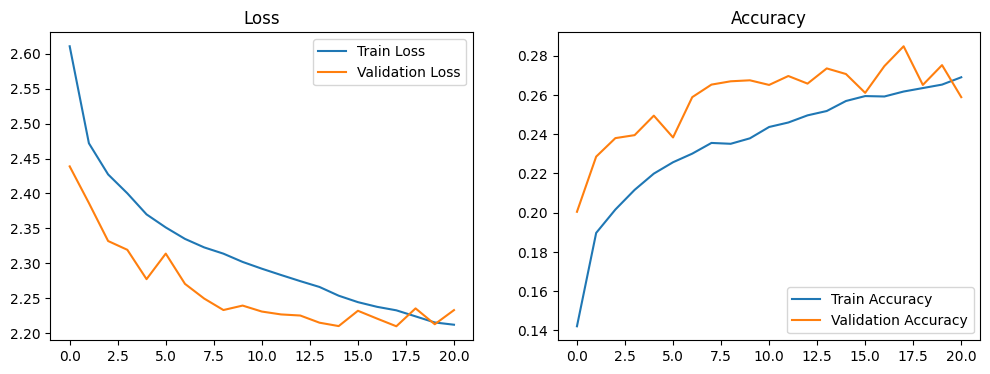

Epoch 1/30 - loss: 2.6252 - acc: 0.1338 - val_loss: 2.4789 - val_acc: 0.2043
Epoch 2/30 - loss: 2.4985 - acc: 0.1725 - val_loss: 2.3977 - val_acc: 0.2047
Epoch 3/30 - loss: 2.4672 - acc: 0.1858 - val_loss: 2.3670 - val_acc: 0.2313
Epoch 4/30 - loss: 2.4352 - acc: 0.1966 - val_loss: 2.3305 - val_acc: 0.2350
Epoch 5/30 - loss: 2.4072 - acc: 0.2049 - val_loss: 2.3141 - val_acc: 0.2407
Epoch 6/30 - loss: 2.3858 - acc: 0.2128 - val_loss: 2.3044 - val_acc: 0.2424
Epoch 7/30 - loss: 2.3709 - acc: 0.2184 - val_loss: 2.3343 - val_acc: 0.2318
Epoch 8/30 - loss: 2.3567 - acc: 0.2207 - val_loss: 2.4096 - val_acc: 0.2117
Epoch 9/30 - loss: 2.3446 - acc: 0.2279 - val_loss: 2.2751 - val_acc: 0.2495
Epoch 10/30 - loss: 2.3329 - acc: 0.2260 - val_loss: 2.2511 - val_acc: 0.2558
Epoch 11/30 - loss: 2.3220 - acc: 0.2325 - val_loss: 2.2482 - val_acc: 0.2604
Epoch 12/30 - loss: 2.3120 - acc: 0.2360 - val_loss: 2.2543 - val_acc: 0.2619
Epoch 13/30 - loss: 2.3067 - acc: 0.2365 - val_loss: 2.2657 - val_acc: 0.

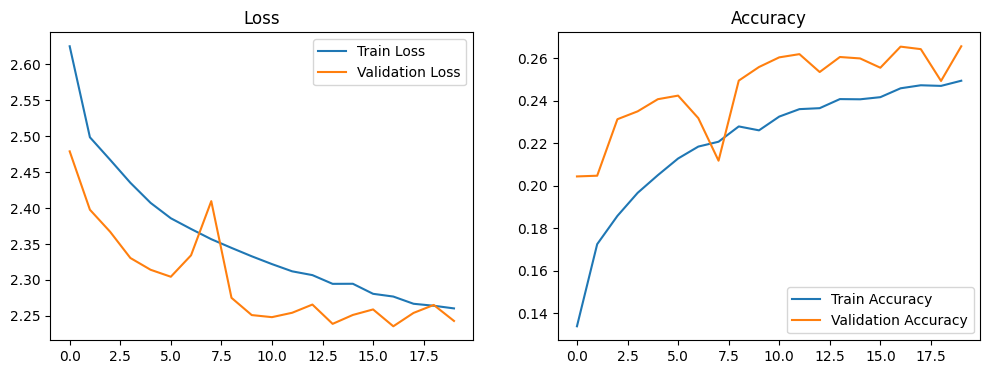

Epoch 1/30 - loss: 2.5774 - acc: 0.1556 - val_loss: 2.4130 - val_acc: 0.2227
Epoch 2/30 - loss: 2.4608 - acc: 0.1907 - val_loss: 2.3760 - val_acc: 0.2314
Epoch 3/30 - loss: 2.4210 - acc: 0.2053 - val_loss: 2.3290 - val_acc: 0.2412
Epoch 4/30 - loss: 2.3981 - acc: 0.2108 - val_loss: 2.3214 - val_acc: 0.2399
Epoch 5/30 - loss: 2.3743 - acc: 0.2184 - val_loss: 2.3079 - val_acc: 0.2535
Epoch 6/30 - loss: 2.3531 - acc: 0.2215 - val_loss: 2.2797 - val_acc: 0.2584
Epoch 7/30 - loss: 2.3376 - acc: 0.2264 - val_loss: 2.2569 - val_acc: 0.2543
Epoch 8/30 - loss: 2.3247 - acc: 0.2320 - val_loss: 2.2483 - val_acc: 0.2631
Epoch 9/30 - loss: 2.3087 - acc: 0.2344 - val_loss: 2.2693 - val_acc: 0.2527
Epoch 10/30 - loss: 2.3018 - acc: 0.2369 - val_loss: 2.2563 - val_acc: 0.2565
Epoch 11/30 - loss: 2.2900 - acc: 0.2381 - val_loss: 2.2259 - val_acc: 0.2649
Epoch 12/30 - loss: 2.2801 - acc: 0.2424 - val_loss: 2.2420 - val_acc: 0.2673
Epoch 13/30 - loss: 2.2744 - acc: 0.2442 - val_loss: 2.2399 - val_acc: 0.

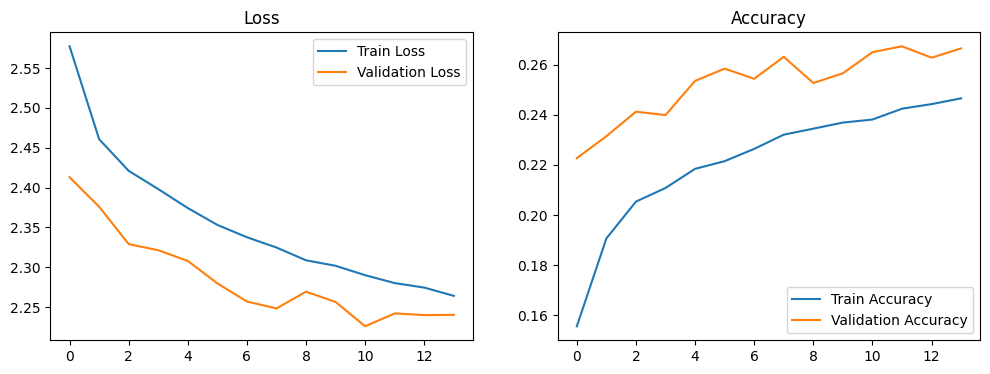

In [9]:
input_channels = X_train.shape[1]

n_estimators = 5
# n_estimators = 3
bagging_models = []

for i in range(n_estimators):

    X_bagging_train, _, y_bagging_train, _ = train_test_split(
        X_train,
        y_train_numerical,
        test_size=0.35,
        stratify=y_train_numerical,
        random_state=42 + i
    )

    model, history = train_and_evaluate(
        X_bagging_train,
        y_bagging_train,
        X_test,
        y_test_numerical,
        input_channels,
        num_classes,
        max_length,
        learning_rate=0.001,
        dropout_rate=0.4,
        l2_reg=0.0005,
        batch_size=128,
        epochs=30,
        patience=3
    )

    # model, history = train_and_evaluate(
    #     X_bagging_train,
    #     y_bagging_train,
    #     X_test,
    #     y_test_numerical,
    #     input_channels,
    #     num_classes,
    #     max_length,
    #     learning_rate=0.001,
    #     dropout_rate=0.5,
    #     l2_reg=0.001,
    #     batch_size=16,
    #     epochs=50,
    #     patience=5
    # )

    plot_training_history(history)
    bagging_models.append(model)

# save
os.makedirs('models/bagged_cnn_models', exist_ok=True)

for i, model in enumerate(bagging_models):
    torch.save(model.state_dict(), f'./models/bagged_cnn_models/bagged_cnn_model_{i}.pth')

In [18]:
# Use the average prediction of the bagging models
y_preds = []

for model in bagging_models:
    model.eval()
    model.to(device)

    with torch.no_grad():
        inputs = X_test.to(device)

        outputs = model(inputs)
        y_pred = torch.softmax(outputs, dim=1)

    y_preds.append(y_pred.cpu().numpy())

y_preds_mean = np.mean(y_preds, axis=0)
y_preds_mean_numerical = np.argmax(y_preds_mean, axis=1)

score = accuracy_score(y_test_numerical, y_preds_mean_numerical)
cm = confusion_matrix(y_test_numerical, y_preds_mean_numerical)
report = classification_report(
    y_test_numerical,
    y_preds_mean_numerical,
    zero_division=0
)

print("Classification Report:\n", report)
print("Confusion Matrix:\n", cm)
print(f"Accuracy: {score}")

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.95      0.95      2122
           1       0.89      0.94      0.91      1684
           2       0.93      0.93      0.93      1963
           3       0.93      0.95      0.94      1806
           4       0.97      0.81      0.89       926
           5       0.91      0.91      0.91      1756

    accuracy                           0.92     10257
   macro avg       0.93      0.91      0.92     10257
weighted avg       0.93      0.92      0.92     10257

Confusion Matrix:
 [[2016   27   48   12    2   17]
 [  20 1580   20   18   19   27]
 [  38   22 1820   34    0   49]
 [   1   34   16 1707    0   48]
 [  22   86   17   25  752   24]
 [  28   34   44   47    0 1603]]
Accuracy: 0.9240518670176465


In [19]:
unique_true = np.unique(y_test_numerical)
unique_pred = np.unique(y_preds_mean_numerical)

print("Classes in test set:     ", unique_true)
print("Classes predicted:      ", unique_pred)

missing_predictions = np.setdiff1d(unique_true, unique_pred)

print("Classes never predicted:", missing_predictions)

Classes in test set:      [0 1 2 3 4 5]
Classes predicted:       [0 1 2 3 4 5]
Classes never predicted: []


# Meta Model

In [ ]:
def get_bagged_model_predictions(models, X, batch_size=16):
    dataset = torch.utils.data.TensorDataset(torch.as_tensor(X, dtype=torch.float32))
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False)

    all_model_predictions = []

    for model in models:
        model.to(device)
        model.eval()

        model_predictions = []

        with torch.no_grad():
            for (inputs,) in dataloader:
                inputs = inputs.to(device)
                outputs = model(inputs)
                probabilities = torch.softmax(outputs, dim=1)
                model_predictions.append(probabilities.cpu())

        model_predictions = torch.cat(model_predictions, dim=0)
        all_model_predictions.append(model_predictions)

        # move model back to CPU before loading the next model onto the GPU.
        model.cpu()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    # [num_models, num_samples, num_classes]
    all_model_predictions = torch.stack(all_model_predictions)

    # Average predictions across models
    # [num_samples, num_classes]
    y_preds_mean = all_model_predictions.mean(dim=0)

    return y_preds_mean

In [ ]:
X_additional_train = np.array([
    additional_features[beatmap_id]
    for beatmap_id in beatmap_ids_train
])

X_additional_test = np.array([
    additional_features[beatmap_id]
    for beatmap_id in beatmap_ids_test
])

bagged_model_train_predictions = get_bagged_model_predictions(bagging_models, X_train)
bagged_model_test_predictions = get_bagged_model_predictions(bagging_models, X_test)

X_meta_train = np.hstack((X_additional_train, bagged_model_train_predictions))
X_meta_test = np.hstack((X_additional_test, bagged_model_test_predictions))

In [22]:
from sklearn.ensemble import RandomForestClassifier

meta_model = RandomForestClassifier(n_estimators=100, random_state=42)
meta_model.fit(X_meta_train, y_train_numerical)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [23]:
y_meta_pred_numerical = meta_model.predict(X_meta_test)
meta_score = accuracy_score(y_test_numerical, y_meta_pred_numerical)
meta_cm = confusion_matrix(y_test_numerical, y_meta_pred_numerical)
meta_report = classification_report(
    y_test_numerical,
    y_meta_pred_numerical,
    labels=np.arange(len(label_encoder.classes_)),
    target_names=label_encoder.classes_,
    zero_division=0
)

print("Meta-model Classification Report:\n", meta_report)
print("Meta-model Confusion Matrix:\n", meta_cm)
print(f"Meta-model Accuracy: {meta_score}")

Meta-model Classification Report:
               precision    recall  f1-score   support

         NM1       0.99      0.98      0.98      2122
         NM2       0.97      0.96      0.97      1684
         NM3       0.97      0.97      0.97      1963
         NM4       0.97      0.98      0.98      1806
         NM5       0.96      0.95      0.96       926
         NM6       0.95      0.96      0.96      1756

    accuracy                           0.97     10257
   macro avg       0.97      0.97      0.97     10257
weighted avg       0.97      0.97      0.97     10257

Meta-model Confusion Matrix:
 [[2085    1   18    7    0   11]
 [   3 1625    1    9   32   14]
 [   8    3 1909    9    0   34]
 [   1    8    6 1763    1   27]
 [   4   29    6    3  884    0]
 [  12    5   31   18    0 1690]]
Meta-model Accuracy: 0.9706541873842254


In [24]:
print("Classes in full dataset:", len(label_encoder.classes_))
print("Classes in test set:", len(np.unique(y_test_numerical)))
print("Classes predicted:", len(np.unique(y_meta_pred_numerical)))

Classes in full dataset: 6
Classes in test set: 6
Classes predicted: 6


# Bagging vs Pruning the CNN models


### Training

In [25]:
pruned_models = prune_models(bagging_models, X_train, y_train_numerical)

os.makedirs('models/pruned_models', exist_ok=True)

for i, model in enumerate(bagging_models):
    torch.save(model.state_dict(), f'./models/pruned_models/pruned_model_{i}.pth')


Pruning model 1/5
  Epoch 1/2 - target sparsity: 30%
    Fine-tune loss: 0.5514
  Epoch 2/2 - target sparsity: 50%
    Fine-tune loss: 0.6033

Pruning model 2/5
  Epoch 1/2 - target sparsity: 30%
    Fine-tune loss: 0.5781
  Epoch 2/2 - target sparsity: 50%
    Fine-tune loss: 0.6309

Pruning model 3/5
  Epoch 1/2 - target sparsity: 30%
    Fine-tune loss: 0.4996
  Epoch 2/2 - target sparsity: 50%
    Fine-tune loss: 0.5359

Pruning model 4/5
  Epoch 1/2 - target sparsity: 30%
    Fine-tune loss: 0.5524
  Epoch 2/2 - target sparsity: 50%
    Fine-tune loss: 0.5872

Pruning model 5/5
  Epoch 1/2 - target sparsity: 30%
    Fine-tune loss: 0.5449
  Epoch 2/2 - target sparsity: 50%
    Fine-tune loss: 0.5804


### Testing

In [26]:
# ---------------------------------------------------------
# Load bagged CNN models
# ---------------------------------------------------------

start = time.perf_counter()

model_folder = "./models/bagged_cnn_models/"

model_kwargs = {
    "input_channels": 4,
    "num_classes": num_classes,
    "max_length": max_length,
    "dropout_rate": 0.5
}

bagged_models = load_pytorch_models(
    model_folder,
    CNN_Model,
    model_kwargs,
    device
)

end = time.perf_counter()

print(
    f"Loaded {len(bagged_models)} bagged models "
    f"in {end - start:.4f} seconds"
)


# ---------------------------------------------------------
# Load pruned CNN models
# ---------------------------------------------------------

start = time.perf_counter()

model_folder = "./models/pruned_models/"

stripped_pruned = load_pytorch_models(
    model_folder,
    CNN_Model,
    model_kwargs,
    device
)

end = time.perf_counter()

print(
    f"Loaded {len(stripped_pruned)} pruned models "
    f"in {end - start:.4f} seconds"
)

Loaded 5 bagged models in 0.0963 seconds
Loaded 5 pruned models in 0.0845 seconds


In [27]:
# ---------------------------------------------------------
# Prepare test data
# ---------------------------------------------------------

target_names = label_encoder.classes_
labels = np.arange(len(label_encoder.classes_))

In [28]:
# ---------------------------------------------------------
# Bagged CNN models
# ---------------------------------------------------------

start = time.perf_counter()

y_preds_mean = get_bagged_model_predictions(
    bagged_models,
    X_test,
    batch_size=16
)

end = time.perf_counter()

print(f"Bagged prediction time: {end - start:.4f} seconds")

y_preds_mean_numerical = y_preds_mean.argmax(dim=1).numpy()


score = accuracy_score(
    y_test_numerical,
    y_preds_mean_numerical
)

cm = confusion_matrix(
    y_test_numerical,
    y_preds_mean_numerical,
    labels=labels
)

report = classification_report(
    y_test_numerical,
    y_preds_mean_numerical,
    labels=labels,
    target_names=target_names,
    zero_division=0
)

print("\n========== BAGGED CNN MODELS ==========")
print("Classification Report:\n", report)
print("Confusion Matrix:\n", cm)
print(f"Accuracy: {score:.4f}")

Bagged prediction time: 2.3295 seconds

========== BAGGED CNN MODELS ==========
Classification Report:
               precision    recall  f1-score   support

         NM1       0.95      0.95      0.95      2122
         NM2       0.89      0.94      0.91      1684
         NM3       0.93      0.93      0.93      1963
         NM4       0.93      0.95      0.94      1806
         NM5       0.97      0.81      0.89       926
         NM6       0.91      0.91      0.91      1756

    accuracy                           0.92     10257
   macro avg       0.93      0.91      0.92     10257
weighted avg       0.93      0.92      0.92     10257

Confusion Matrix:
 [[2016   27   48   12    2   17]
 [  20 1580   20   18   19   27]
 [  38   22 1820   34    0   49]
 [   1   34   16 1707    0   48]
 [  22   86   17   25  752   24]
 [  28   34   44   47    0 1603]]
Accuracy: 0.9241


In [29]:
# ---------------------------------------------------------
# Pruned CNN models
# ---------------------------------------------------------

start = time.perf_counter()

y_pruned_preds_mean = get_bagged_model_predictions(
    pruned_models,
    X_test,
    batch_size=16
)

end = time.perf_counter()

print(f"Pruned prediction time: {end - start:.4f} seconds")

y_pruned_preds_mean_numerical = (
    y_pruned_preds_mean.argmax(dim=1).numpy()
)


score_pruned = accuracy_score(
    y_test_numerical,
    y_pruned_preds_mean_numerical
)

cm_pruned = confusion_matrix(
    y_test_numerical,
    y_pruned_preds_mean_numerical,
    labels=labels
)

report_pruned = classification_report(
    y_test_numerical,
    y_pruned_preds_mean_numerical,
    labels=labels,
    target_names=target_names,
    zero_division=0
)

print("\n========== PRUNED CNN MODELS ==========")
print("Classification Report:\n", report_pruned)
print("Confusion Matrix:\n", cm_pruned)
print(f"Accuracy: {score_pruned:.4f}")

Pruned prediction time: 2.4792 seconds

========== PRUNED CNN MODELS ==========
Classification Report:
               precision    recall  f1-score   support

         NM1       0.95      0.96      0.95      2122
         NM2       0.89      0.94      0.91      1684
         NM3       0.93      0.92      0.93      1963
         NM4       0.92      0.95      0.94      1806
         NM5       0.97      0.79      0.87       926
         NM6       0.91      0.92      0.92      1756

    accuracy                           0.93     10257
   macro avg       0.93      0.91      0.92     10257
weighted avg       0.93      0.93      0.93     10257

Confusion Matrix:
 [[2039   26   33   11    0   13]
 [  23 1587   12   21   19   22]
 [  40   20 1804   41    0   58]
 [   0   34   18 1717    0   37]
 [  29   84   25   28  731   29]
 [  25   37   40   39    0 1615]]
Accuracy: 0.9255
